# DeliveryETA — Prédiction du Temps de Livraison

## Objectif du projet

L'objectif de ce projet est de développer un modèle de Machine Learning capable de prédire le temps nécessaire pour livrer une commande.

La variable cible du projet est :

`Time_taken(min)`

Le modèle utilisera différentes informations concernant la commande, le livreur, le trajet, le trafic, la météo et les conditions de livraison.

## Objectifs business

La prédiction du temps de livraison peut permettre de :

- fournir une estimation du délai au client ;
- améliorer la planification des livraisons ;
- aider à l'affectation des livreurs ;
- identifier les facteurs qui influencent le temps de livraison ;
- améliorer l'organisation des opérations de livraison.

## Dataset

Le dataset contient 45 593 observations et 20 variables.

Les informations disponibles concernent notamment :

- le livreur ;
- la position du restaurant et du client ;
- la date et l'heure de la commande ;
- les conditions météorologiques ;
- le trafic routier ;
- le véhicule ;
- le type de commande ;
- les livraisons multiples ;
- les festivals ;
- la ville ;
- le temps réel de livraison.

## Variable cible

La variable que nous voulons prédire est :

`Time_taken(min)`

Elle représente le temps de livraison en minutes.

## 1. Importation des bibliothèques

Nous importons les bibliothèques nécessaires pour charger, manipuler, analyser et visualiser les données.

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

## 2. Chargement du dataset

Nous chargeons le fichier CSV contenant les données de livraison à l'aide de Pandas.

In [4]:
df = pd.read_csv("../data/dataset_food_delivery.csv")

## 3. Compréhension initiale des données

Avant de commencer le nettoyage, nous allons examiner la structure et les caractéristiques générales du dataset.

Nous allons vérifier :

- le nombre de lignes et de colonnes ;
- les noms des colonnes ;
- les premières observations ;
- les types de données ;
- les valeurs manquantes.

In [5]:
print(df.head())

        ID Delivery_person_ID Delivery_person_Age Delivery_person_Ratings  \
0  0x4607     INDORES13DEL02                   37                     4.9   
1  0xb379     BANGRES18DEL02                   34                     4.5   
2  0x5d6d     BANGRES19DEL01                   23                     4.4   
3  0x7a6a    COIMBRES13DEL02                   38                     4.7   
4  0x70a2     CHENRES12DEL01                   32                     4.6   

   Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
0            22.745049             75.892471                   22.765049   
1            12.913041             77.683237                   13.043041   
2            12.914264             77.678400                   12.924264   
3            11.003669             76.976494                   11.053669   
4            12.972793             80.249982                   13.012793   

   Delivery_location_longitude  Order_Date Time_Orderd Time_Order_picked  \
0   

In [6]:
print(df.shape)

(45593, 20)


In [7]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          45593 non-null  str    
 3   Delivery_person_Ratings      45593 non-null  str    
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  45593 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            45593 non-null  str    
 12  Road_traffic_density         45593 non-null  str    
 13  Vehicle_condition          

In [8]:
print(df.isnull().sum())

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64


In [9]:
print(df.duplicated().sum())

0


In [10]:
print(df.columns.tolist())


['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)']


In [11]:
print(df.describe())

       Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
count         45593.000000          45593.000000                45593.000000   
mean             17.017729             70.231332                   17.465186   
std               8.185109             22.883647                    7.335122   
min             -30.905562            -88.366217                    0.010000   
25%              12.933284             73.170000                   12.988453   
50%              18.546947             75.898497                   18.633934   
75%              22.728163             78.044095                   22.785049   
max              30.914057             88.433452                   31.054057   

       Delivery_location_longitude  Vehicle_condition  
count                 45593.000000       45593.000000  
mean                     70.845702           1.023359  
std                      21.118812           0.839065  
min                       0.010000           0.000000  

In [12]:
print(clean_df.dtypes)

NameError: name 'clean_df' is not defined

In [13]:
# last 5 rows
print(df.tail())

            ID Delivery_person_ID Delivery_person_Age Delivery_person_Ratings  \
45588  0x7c09      JAPRES04DEL01                   30                     4.8   
45589  0xd641      AGRRES16DEL01                   21                     4.6   
45590  0x4f8d     CHENRES08DEL03                   30                     4.9   
45591  0x5eee    COIMBRES11DEL01                   20                     4.7   
45592  0x5fb2   RANCHIRES09DEL02                   23                     4.9   

       Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
45588            26.902328             75.794257                   26.912328   
45589             0.000000              0.000000                    0.070000   
45590            13.022394             80.242439                   13.052394   
45591            11.001753             76.986241                   11.041753   
45592            23.351058             85.325731                   23.431058   

       Delivery_location_longitu

Cleaning Data


In [14]:
clean_df = df.copy()
print(clean_df.duplicated().sum())
print(clean_df["ID"].duplicated().sum())


#print(clean_df["Traffic_Level"].value_counts())



0
0


###  Vérification des variables numériques

Certaines variables qui devraient être numériques sont actuellement stockées sous forme de texte (`str`).

Nous allons inspecter leurs valeurs avant de les convertir afin d'identifier d'éventuelles valeurs particulières ou incohérentes.

In [15]:
print(clean_df["Delivery_person_Age"].unique()[:30])
print(clean_df["Delivery_person_Ratings"].unique()[:30])
print(clean_df["multiple_deliveries"].unique())
print(clean_df["Time_taken(min)"].unique()[:20])

<ArrowStringArray>
[  '37',   '34',   '23',   '38',   '32',   '22',   '33',   '35',   '36',
   '21',   '24',   '29',   '25',   '31',   '27',   '26',   '20', 'NaN ',
   '28',   '39',   '30',   '15',   '50']
Length: 23, dtype: str
<ArrowStringArray>
[ '4.9',  '4.5',  '4.4',  '4.7',  '4.6',  '4.8',  '4.2',  '4.3',    '4',
  '4.1',    '5',  '3.5', 'NaN ',  '3.8',  '3.9',  '3.7',  '2.6',  '2.5',
  '3.6',  '3.1',  '2.7',    '1',  '3.2',  '3.3',    '6',  '3.4',  '2.8',
  '2.9',    '3']
Length: 29, dtype: str
<ArrowStringArray>
['0', '1', '3', 'NaN ', '2']
Length: 5, dtype: str
<ArrowStringArray>
['(min) 24', '(min) 33', '(min) 26', '(min) 21', '(min) 30', '(min) 40',
 '(min) 32', '(min) 34', '(min) 46', '(min) 23', '(min) 20', '(min) 41',
 '(min) 15', '(min) 36', '(min) 39', '(min) 18', '(min) 38', '(min) 47',
 '(min) 12', '(min) 22']
Length: 20, dtype: str


### 4.5 Nettoyage des valeurs manquantes textuelles

Certaines valeurs manquantes sont représentées sous forme de texte, par exemple `"NaN "`.

Pandas ne les considère donc pas comme de vraies valeurs manquantes.

Nous allons les remplacer par `NaN` afin que Pandas puisse les détecter et les traiter correctement.

In [16]:
clean_df = clean_df.replace("NaN ",np.nan)
print(clean_df.isnull().sum())


ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64


###  Nettoyage de la variable cible

La variable cible `Time_taken(min)` contient actuellement le texte `(min)`.

Nous allons supprimer cette partie afin d'obtenir une variable numérique représentant le temps de livraison en minutes.

In [17]:
clean_df["Time_taken(min)"] = (clean_df["Time_taken(min)"].str.replace("(min)","",regex=False).str.strip().astype(int))
print(clean_df["Time_taken(min)"].head)
print(clean_df["Time_taken(min)"].dtype)



<bound method NDFrame.head of 0        24
1        33
2        26
3        21
4        30
         ..
45588    32
45589    36
45590    16
45591    26
45592    36
Name: Time_taken(min), Length: 45593, dtype: int64>
int64


###  Analyse de la densité du trafic

La variable `Road_traffic_density` représente le niveau de trafic routier.

Il s'agit d'une variable catégorielle avec plusieurs niveaux :

- `Low` : trafic faible
- `Medium` : trafic moyen
- `High` : trafic élevé
- `Jam` : embouteillage important

Nous vérifions la fréquence de chaque catégorie ainsi que les valeurs manquantes.

In [18]:
print(clean_df["Road_traffic_density"].value_counts(dropna=False))

clean_df["Road_traffic_density"] = clean_df["Road_traffic_density"].fillna("Unknown")

print(clean_df["Road_traffic_density"].value_counts(dropna=False))


Road_traffic_density
Low        15477
Jam        14143
Medium     10947
High        4425
NaN          601
Name: count, dtype: int64
Road_traffic_density
Low        15477
Jam        14143
Medium     10947
High        4425
Unknown      601
Name: count, dtype: int64


### Vérification de `multiple_deliveries`

La variable `multiple_deliveries` indique le nombre de livraisons multiples associées à une commande.

Nous allons vérifier la fréquence de chaque valeur, y compris les valeurs manquantes.

In [19]:
print(clean_df["multiple_deliveries"].value_counts(dropna=False))
clean_df["multiple_deliveries"].dtype

clean_df["multiple_deliveries"] = pd.to_numeric(
    clean_df["multiple_deliveries"],
    errors="coerce" # valuee can't converted = NaN not stop convert
)

multiple_deliveries
1      28159
0      14095
2       1985
NaN      993
3        361
Name: count, dtype: int64


### Vérification de `Delivery_person_Age`

La variable `Delivery_person_Age` représente l'âge du livreur.

Avant de convertir cette colonne en numérique, nous allons vérifier :
- les différentes valeurs présentes ;
- les valeurs manquantes ;
- la distribution des âges ;
- la présence éventuelle de valeurs inhabituelles.

In [20]:
clean_df["Delivery_person_Age"].value_counts(dropna=False).sort_index()

clean_df["Delivery_person_Age"]= pd.to_numeric(
    clean_df["Delivery_person_Age"],
    errors="coerce"
)

clean_df["Delivery_person_Age"].describe()

count    43739.000000
mean        29.567137
std          5.815155
min         15.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         50.000000
Name: Delivery_person_Age, dtype: float64

###  Vérification de `Delivery_person_Ratings`

La variable `Delivery_person_Ratings` représente la note attribuée au livreur.

Avant de la convertir en numérique, nous allons vérifier :
- les différentes valeurs présentes ;
- les valeurs manquantes ;
- les valeurs éventuellement inhabituelles.

In [21]:
clean_df["Delivery_person_Ratings"].value_counts(dropna=False).sort_index()


Delivery_person_Ratings
1        38
2.5      20
2.6      22
2.7      22
2.8      19
2.9      19
3         6
3.1      29
3.2      29
3.3      25
3.4      32
3.5     249
3.6     207
3.7     225
3.8     228
3.9     197
4      1077
4.1    1430
4.2    1418
4.3    1409
4.4    1361
4.5    3303
4.6    6940
4.7    7142
4.8    7148
4.9    7041
5      3996
6        53
NaN    1908
Name: count, dtype: int64

###  Vérification des valeurs invalides

Après la conversion en numérique, nous allons vérifier les valeurs de `Delivery_person_Ratings` qui dépassent la plage attendue de 1 à 5.

Nous allons identifier ces valeurs avant de décider comment les traiter.

In [42]:
clean_df["Delivery_person_Ratings"] = pd.to_numeric(
    clean_df["Delivery_person_Ratings"],
    errors="coerce"
)

clean_df[clean_df["Delivery_person_Ratings"] > 5]["Delivery_person_Ratings"].value_counts()

Delivery_person_Ratings
6.0    53
Name: count, dtype: int64

In [24]:
clean_df= clean_df.drop(
    columns=[
        "ID",
        "Delivery_person_ID",
        "City",
        "Festival"
    ]
)

print(clean_df.columns.tolist())

['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Time_taken(min)']


### Traitement des valeurs invalides de `Delivery_person_Ratings`

Les notes des livreurs sont normalement comprises entre 1 et 5.

Nous avons identifié 53 valeurs égales à 6, qui dépassent la plage attendue.

Nous allons remplacer ces valeurs invalides par `NaN` afin de les traiter comme des valeurs manquantes.

In [43]:
clean_df.loc[
    clean_df["Delivery_person_Ratings"] > 5,
    "Delivery_person_Ratings"
] = np.nan

clean_df["Delivery_person_Ratings"].value_counts(
    dropna=False
).sort_index()

Delivery_person_Ratings
1.0      38
2.5      20
2.6      22
2.7      22
2.8      19
2.9      19
3.0       6
3.1      29
3.2      29
3.3      25
3.4      32
3.5     249
3.6     207
3.7     225
3.8     228
3.9     197
4.0    1077
4.1    1430
4.2    1418
4.3    1409
4.4    1361
4.5    3303
4.6    6940
4.7    7142
4.8    7148
4.9    7041
5.0    3996
NaN    1961
Name: count, dtype: int64

###  Vérification de `Delivery_person_Ratings`

Après avoir remplacé les valeurs invalides par `NaN`, nous vérifions que les notes restantes sont bien comprises entre 1 et 5.

In [50]:
clean_df[
    "Delivery_person_Ratings"
    ].describe()

count    45593.000000
mean         4.635040
std          0.324598
min          1.000000
25%          4.600000
50%          4.700000
75%          4.800000
max          5.000000
Name: Delivery_person_Ratings, dtype: float64

In [45]:
rating_median = clean_df["Delivery_person_Ratings"].median()

print(rating_median)

4.7


In [48]:
print(clean_df["Delivery_person_Ratings"].isna().sum())

clean_df["Delivery_person_Ratings"] = clean_df["Delivery_person_Ratings"].fillna(rating_median)

print(clean_df["Delivery_person_Ratings"].isna().sum())

1961
0


###  Vérification des coordonnées géographiques

Les coordonnées géographiques permettent de localiser le restaurant et le lieu de livraison.

Nous allons vérifier les valeurs minimales et maximales afin de détecter d'éventuelles valeurs inhabituelles avant de calculer la distance.

In [28]:
clean_df[
    [
        "Restaurant_latitude",
        "Restaurant_longitude",
        "Delivery_location_latitude",
        "Delivery_location_longitude"
    ]
].describe()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
count,45593.000000,45593.000000,45593.000000,45593.000000
mean,17.017729,70.231332,17.465186,70.845702
std,8.185109,22.883647,7.335122,21.118812
min,-30.905562,-88.366217,0.010000,0.010000
25%,12.933284,73.170000,12.988453,73.280000
50%,18.546947,75.898497,18.633934,76.002574
75%,22.728163,78.044095,22.785049,78.107044
max,30.914057,88.433452,31.054057,88.563452


In [29]:
clean_df[
    [
        "Restaurant_latitude",
        "Restaurant_longitude",
        "Delivery_location_latitude",
        "Delivery_location_longitude"
    ]
].isnull().sum()

Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
dtype: int64

In [30]:
clean_df[
    (clean_df["Delivery_location_latitude"] == 0.01) |
    (clean_df["Delivery_location_longitude"] == 0.01)
].shape

(327, 16)

In [31]:
clean_df[
    (clean_df["Delivery_location_latitude"] == 0.01) |
    (clean_df["Delivery_location_longitude"] == 0.01)
][
    [
        "Delivery_location_latitude",
        "Delivery_location_longitude"
    ]
].head()

,Delivery_location_latitude,Delivery_location_longitude
153,0.01,0.01
359,0.01,0.01
468,0.01,0.01
610,0.01,0.01
643,0.01,0.01


In [32]:
clean_df.loc[
    (
        (clean_df["Delivery_location_latitude"] == 0.01) |
        (clean_df["Delivery_location_longitude"] == 0.01)
    ),
    [
        "Delivery_location_latitude",
        "Delivery_location_longitude"
    ]
] = np.nan



In [33]:
clean_df[
    [
        "Delivery_location_latitude",
        "Delivery_location_longitude"
    ]
].isna().sum()

Delivery_location_latitude     327
Delivery_location_longitude    327
dtype: int64

In [34]:
clean_df.isna().sum()
print(clean_df.head())


   Delivery_person_Age Delivery_person_Ratings  Restaurant_latitude  \
0                 37.0                     4.9            22.745049   
1                 34.0                     4.5            12.913041   
2                 23.0                     4.4            12.914264   
3                 38.0                     4.7            11.003669   
4                 32.0                     4.6            12.972793   

   Restaurant_longitude  Delivery_location_latitude  \
0             75.892471                   22.765049   
1             77.683237                   13.043041   
2             77.678400                   12.924264   
3             76.976494                   11.053669   
4             80.249982                   13.012793   

   Delivery_location_longitude  Order_Date Time_Orderd Time_Order_picked  \
0                    75.912471  19-03-2022    11:30:00          11:45:00   
1                    77.813237  25-03-2022    19:45:00          19:50:00   
2             

### Vérification de l'âge des livreurs

Nous vérifions les valeurs minimales, maximales et la distribution des âges afin d'identifier d'éventuelles valeurs anormales avant de traiter les valeurs manquantes.

In [35]:
clean_df["Delivery_person_Age"].describe()

clean_df["Delivery_person_Age"].value_counts(dropna=False).sort_index()

Delivery_person_Age
15.0      38
20.0    2136
21.0    2153
22.0    2196
23.0    2087
24.0    2210
25.0    2174
26.0    2159
27.0    2150
28.0    2179
29.0    2191
30.0    2226
31.0    2120
32.0    2202
33.0    2187
34.0    2166
35.0    2262
36.0    2260
37.0    2227
38.0    2219
39.0    2144
50.0      53
NaN     1854
Name: count, dtype: int64

In [36]:
clean_df[
    (clean_df["Delivery_person_Age"] == 15) |
    (clean_df["Delivery_person_Age"] == 50)
][
    [
        "Delivery_person_Age",
        "Delivery_person_Ratings",
        "Vehicle_condition",
        "Time_taken(min)"
    ]
].head(20)

,Delivery_person_Age,Delivery_person_Ratings,Vehicle_condition,Time_taken(min)
2387,15.0,1,3,15
2905,15.0,1,3,29
2951,15.0,1,3,20
3586,50.0,6,3,25
4714,50.0,6,3,27
5169,50.0,6,3,20
5362,50.0,6,3,18
5651,50.0,6,3,20
5902,15.0,1,3,25
6394,50.0,6,3,20


###  Visualisation de la distribution de l'âge

Nous visualisons la répartition des âges afin d'identifier les valeurs inhabituelles et de mieux comprendre la distribution des données.

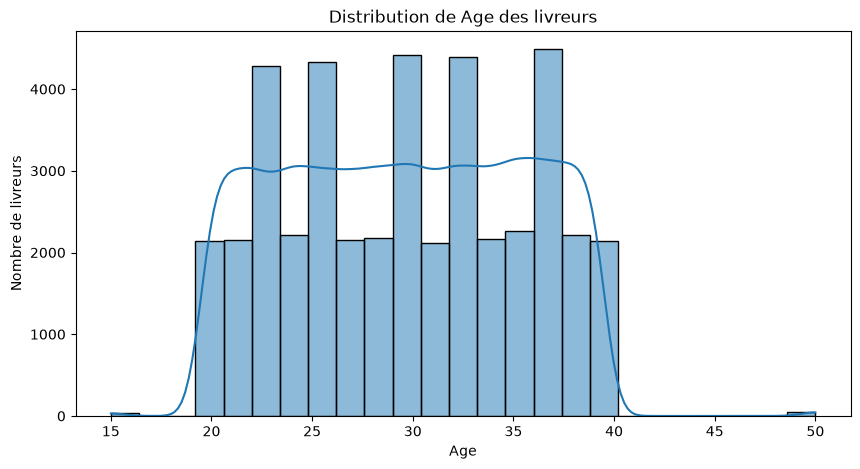

In [37]:
plt.figure(figsize=(10, 5))

sns.histplot(
    clean_df["Delivery_person_Age"],
    bins=25,
    kde=True
)

plt.title("Distribution de Age des livreurs")
plt.xlabel("Age")
plt.ylabel("Nombre de livreurs")
plt.show()

###  Traitement des valeurs manquantes de l'âge

Après l'analyse de la distribution des âges, les valeurs `15` et `50` ont été considérées comme des valeurs inhabituelles dans notre dataset.

Elles ont été remplacées par `NaN` afin de les traiter comme des valeurs manquantes.

Ensuite, les valeurs manquantes ont été remplacées par la **médiane** de l'âge.

La médiane obtenue est de **30 ans**.

Cette méthode permet de conserver les lignes du dataset tout en évitant d'utiliser des valeurs d'âge considérées comme suspectes.

Après le traitement :

- Les âges sont compris entre **20 et 39 ans**.
- Il n'y a plus de valeurs manquantes dans `Delivery_person_Age`.
- Les valeurs inhabituelles `15` et `50` ont été remplacées.
- Les valeurs manquantes ont été imputées avec la médiane `30`.

In [38]:
clean_df.loc[
    (clean_df["Delivery_person_Age"] < 20) |
    (clean_df["Delivery_person_Age"] > 39),
    "Delivery_person_Age"
] = np.nan


clean_df["Delivery_person_Age"].value_counts().sort_index()

clean_df["Delivery_person_Age"] = clean_df["Delivery_person_Age"].fillna(clean_df["Delivery_person_Age"].median())

clean_df["Delivery_person_Age"].value_counts().sort_index()



Delivery_person_Age
20.0    2136
21.0    2153
22.0    2196
23.0    2087
24.0    2210
25.0    2174
26.0    2159
27.0    2150
28.0    2179
29.0    2191
30.0    4171
31.0    2120
32.0    2202
33.0    2187
34.0    2166
35.0    2262
36.0    2260
37.0    2227
38.0    2219
39.0    2144
Name: count, dtype: int64